# 11. Principal Component Analysis (PCA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# --- Load and preprocess churn dataset (Classification) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_churn = pd.read_csv('churn_df.csv')
# Dropping ID columns which have no predictive value
df_churn = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

X_clf = df_churn.drop(columns=['Exited'])
y_clf = df_churn['Exited']

# Handling missing values
X_clf.fillna(X_clf.mean(numeric_only=True), inplace=True)
for col in X_clf.select_dtypes(include=['object']).columns:
    X_clf[col].fillna(X_clf[col].mode()[0], inplace=True)

# Categorical mapping using get_dummies
X_clf = pd.get_dummies(X_clf, drop_first=True)

# Train Test Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Scaling
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)
print("Churn dataset ready for classification!")


Churn dataset ready for classification!


## PCA implementation on Churn dataset

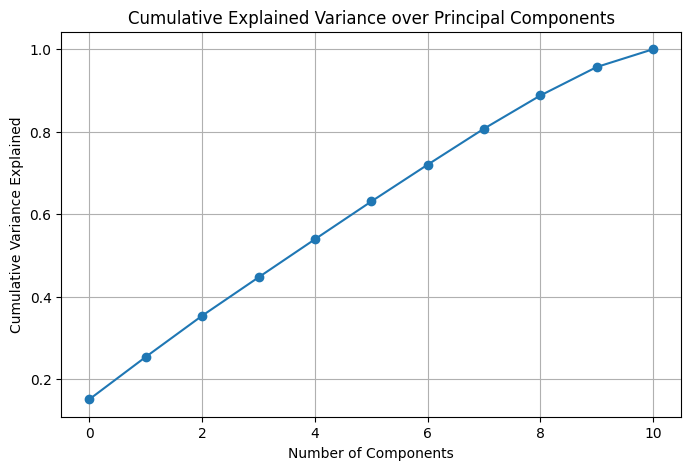

In [3]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_train_clf_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title('Cumulative Explained Variance over Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()


In [4]:
# Apply PCA preserving 90% variance
pca_90 = PCA(n_components=0.90)
X_reduced = pca_90.fit_transform(X_train_clf_scaled)

print("Original dimensions:", X_train_clf_scaled.shape[1])
print("Reduced dimensions to keep 90% variance:", X_reduced.shape[1])


Original dimensions: 11
Reduced dimensions to keep 90% variance: 10
